# **Natural Lanuage Processing Project:**
## *SMS Analysis: Singapore Students and Users*

### **INTRODUCTION**

This project uses the National University of Singapore SMS Corpus, a publicly available dataset released by the National University of Singapore, which contains 67,093 text messages collected as of 9 March 2015. The dataset is made up mainly of SMS messages sent by Singaporean users and students at the university, offering a useful snapshot of everyday, informal communication. It was originally compiled by Tao Chen and Min-Yen Kan and presented in their paper Creating a Live, Public Short Message Service Corpus: The NUS SMS Corpus (2013).

#### **1. Import Libraries and SMS Dataset**

In [103]:
#Import pandas, import dataset and view
import pandas as pd

sms_data = pd.read_csv("clean_nus_sms.csv")

sms_data.head()

,Unnamed: 0,id,Message,length,country,Date
0,0,10120,Bugis oso near wat...,21,SG,2003/4
1,1,10121,"Go until jurong point, crazy.. Available only ...",111,SG,2003/4
2,2,10122,I dunno until when... Lets go learn pilates...,46,SG,2003/4
3,3,10123,Den only weekdays got special price... Haiz......,140,SG,2003/4
4,4,10124,Meet after lunch la...,22,SG,2003/4


#### **2. Data Overview**

In [104]:
# View DataFrame shape
sms_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48598 entries, 0 to 48597
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  48598 non-null  int64 
 1   id          48598 non-null  int64 
 2   Message     48595 non-null  object
 3   length      48598 non-null  object
 4   country     48598 non-null  object
 5   Date        48598 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.2+ MB


**Dataset Description:**

**id:** Unique identifier for each message. <br>
**Message:** The message contents. <br>
**length:**	     Total number of characters in the message. <br>
**country:**	     Country the sender is from. <br>
**Date:**	     Month and Year a message was sent. <br>

Now that I have a clearer understanding of the dataset, I can start to think more carefully about what it can be used for.

One of the most interesting aspects of SMS data is the insight it provides into everyday communication and the themes people talk about in different contexts. Based on this, I will focus on identifying the main topics present in the *Message* column and exploring how these topics vary across countries.

This project will therefore concentrate on topic modelling and thematic analysis of the NUS SMS Corpus. The goal is to uncover the key subjects discussed within the messages and compare how these topics differ between countries represented in the dataset.

#### **3. Exploratory Data Analysis and Clean-up**

In [105]:
print(sms_data.isnull().sum())

Unnamed: 0    0
id            0
Message       3
length        0
country       0
Date          0
dtype: int64


**Notes:**

- The *Message* variable has three null-values, which will need to be investigated. It's likely we can remove these rows.
- All of the values in the DataFrame are objects (strings), except for the id variable.
- There are 48,598 messages present in the DataFrame.


In [106]:
print(sms_data[sms_data.isnull().any(axis=1)])

       Unnamed: 0     id Message length country    Date
3461         3629  13749     NaN      4      SG  2003/4
4593         4807  14927     NaN      3      SG  2003/4
46656       53567  43451     NaN      4     USA  2014/9


In [107]:
#Since there are only a small number of NaN Message rows, I will remove these
sms_data = sms_data.dropna()

In [108]:
#Let's check they have been removed:
print(sms_data.isnull().sum())

Unnamed: 0    0
id            0
Message       0
length        0
country       0
Date          0
dtype: int64


**3.1 Variable EDA: *Country*** <br>

In [109]:
print(sms_data["country"].unique()) 
sms_data["country"].value_counts()

['SG' 'MY' 'India' 'Pakistan' 'United States' 'Canada' 'unknown' 'Serbia'
 'United Kingdom' 'France' 'Singapore' 'China' 'Malaysia' 'Sri Lanka'
 'Spain' 'Bangladesh' 'Philippines' 'Macedonia' 'Romania' 'Kenya'
 'Slovenia' 'New Zealand' 'Nigeria' 'Ghana' 'Indonesia' 'Nepal' 'Morocco'
 'USA' 'Lebanon' 'india' 'Trinidad and Tobago' 'INDIA' 'srilanka'
 'jamaica' 'Hungary' 'Australia' 'Italia' 'BARBADOS' 'Turkey' 'UK']


country
Singapore              22013
SG                      9804
India                   6901
United States           3749
USA                     1931
Sri Lanka               1017
Malaysia                 766
Pakistan                 751
unknown                  602
Canada                   198
Bangladesh               126
China                    107
india                    105
INDIA                     79
Philippines               67
Indonesia                 48
Nepal                     39
srilanka                  30
United Kingdom            30
Hungary                   28
Serbia                    22
Kenya                     20
Ghana                     18
Italia                    10
Turkey                    10
Trinidad and Tobago       10
Lebanon                   10
Slovenia                  10
Nigeria                   10
New Zealand               10
Macedonia                 10
UK                        10
Morocco                    9
Romania                    9
Austra

In [110]:
sms_data["country"] = sms_data["country"].str.strip().str.lower()

# Map variations to clean labels
country_map = {
    "uk": "united kingdom",
    "usa": "united states",
    "my": "malaysia",
    "sg": "singapore",
    "srilanka": "sri Lanka",
}

sms_data["country"] = sms_data["country"].replace(country_map)

print(sorted(sms_data["country"].unique()))

['australia', 'bangladesh', 'barbados', 'canada', 'china', 'france', 'ghana', 'hungary', 'india', 'indonesia', 'italia', 'jamaica', 'kenya', 'lebanon', 'macedonia', 'malaysia', 'morocco', 'nepal', 'new zealand', 'nigeria', 'pakistan', 'philippines', 'romania', 'serbia', 'singapore', 'slovenia', 'spain', 'sri Lanka', 'sri lanka', 'trinidad and tobago', 'turkey', 'united kingdom', 'united states', 'unknown']


<Axes: ylabel='country'>

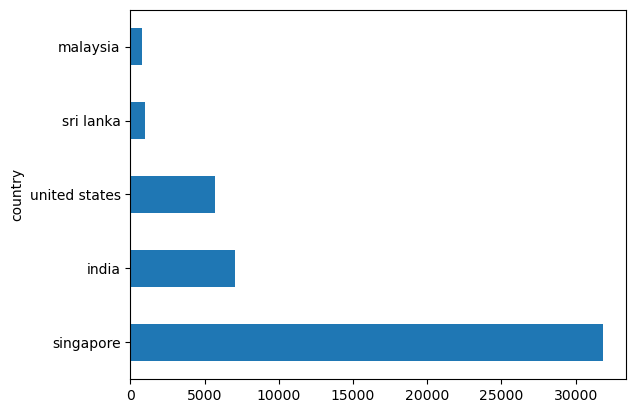

In [111]:
# Number of messages per country
country_value_counts = sms_data['country'].value_counts() 

# Number of messages per country for the top 10 most active countries
top_5_country_value_counts = country_value_counts.head(5) 

# Plot a bar chart using pandas built-in plotting apis
top_5_country_value_counts.plot.barh() 

**3.1.1 Variable EDA: *Country* Outcome** <br>
I can see that there are a number of countries included within this dataset, with the majority originating from (unsurprisingly) Singapore. This could be interesting to explore in later anaylsis.

In preparation for my potential analysis focus on Country SMS sentiment spread, I have cleaned the inputs as I can see there are duplicates for various countries. 

It seems that there are 602 "unknown" countries. If I choose to explore this variable, this will need to be investigated. 

**3.2 Variable EDA: *Date*** <br>

In [112]:
print(sms_data["Date"].unique())

['2003/4' '2010/11' '2010/12' '2011/1' '2011/2' '2011/3' '2011/4' '2011/5'
 '2011/6' '2011/8' '2011/9' '2011/11' '2011/12' '2012/2' '2012/3' '2012/4'
 '2012/5' '2012/6' '2012/7' '2012/8' '2012/10' '2013/5' '2014/9' '2014/11'
 '2014/12' '2015/2' '2015/3']


In [113]:
#Format the date column
sms_data["Date"] = pd.to_datetime(sms_data["Date"], format="%Y/%m")
print(sms_data["Date"].head())

0   2003-04-01
1   2003-04-01
2   2003-04-01
3   2003-04-01
4   2003-04-01
Name: Date, dtype: datetime64[ns]


**3.2.1 Variable EDA: *Date* Outcome** <br>
The date variable is currently listed as a string datatype which will limit my analysis significantly if I wish to sort chronologically or plot over time. 

I have converted this column to the correct format. This will allow me to easily engineer these features later on in my project should I choose to. 

**3.3 Variable EDA: *Length*** <br>

In [114]:
print(sms_data["length"].unique())
print(sms_data["length"].min())
print(sms_data["length"].max())

['21' '111' '46' '140' '22' '65' '51' '81' '160' '33' '41' '132' '23' '26'
 '31' '114' '45' '63' '53' '87' '60' '79' '25' '56' '47' '118' '82' '58'
 '155' '83' '28' '54' '93' '125' '107' '159' '116' '69' '48' '36' '34'
 '122' '142' '76' '14' '27' '97' '38' '119' '32' '133' '101' '74' '123'
 '104' '43' '62' '59' '42' '115' '44' '86' '78' '68' '102' '80' '39' '71'
 '90' '141' '131' '8' '70' '108' '18' '37' '110' '121' '15' '61' '67' '17'
 '96' '10' '24' '9' '19' '52' '16' '13' '3' '7' '20' '5' '75' '29' '11'
 '30' '73' '6' '64' '49' '88' '50' '92' '12' '105' '85' '77' '55' '103'
 '40' '4' '35' '84' '148' '98' '57' '149' '72' '2' '66' '137' '147' '158'
 '151' '94' '91' '95' '153' '89' '109' '134' '100' '156' '99' '135' '136'
 '129' '127' '164' '266' '130' '113' '279' '138' '117' '219' '157' '120'
 '112' '152' '124' '145' '126' '1' '106' '128' '143' '139' '199' '144'
 '167' '154' '165' '146' '168' '162' '200' '161' '189' '292' '150' '210'
 '178' '205' '186' 'Err:511' '171' '202' '252' '183

In [115]:
#Remove error strings
sms_data["length"] = sms_data["length"].str.replace("Err:", "", regex=False)

#Change datatype to numeric
sms_data["length"] = pd.to_numeric(sms_data["length"], errors="coerce")

print(sms_data["length"].isnull().sum())

0


In [116]:
print(sms_data["length"].unique())
print(sms_data["length"].min())
print(sms_data["length"].max())

[ 21 111  46 140  22  65  51  81 160  33  41 132  23  26  31 114  45  63
  53  87  60  79  25  56  47 118  82  58 155  83  28  54  93 125 107 159
 116  69  48  36  34 122 142  76  14  27  97  38 119  32 133 101  74 123
 104  43  62  59  42 115  44  86  78  68 102  80  39  71  90 141 131   8
  70 108  18  37 110 121  15  61  67  17  96  10  24   9  19  52  16  13
   3   7  20   5  75  29  11  30  73   6  64  49  88  50  92  12 105  85
  77  55 103  40   4  35  84 148  98  57 149  72   2  66 137 147 158 151
  94  91  95 153  89 109 134 100 156  99 135 136 129 127 164 266 130 113
 279 138 117 219 157 120 112 152 124 145 126   1 106 128 143 139 199 144
 167 154 165 146 168 162 200 161 189 292 150 210 178 205 186 511 171 202
 252 183 170 604 304 424 436 173 247 262 163 670 288 294 208 884 355 230
 229 296 264 235 176 222 237 191 363 184 234 244 221 790 201 289 415 431
 190 290 379 232 369 276 193 287 240 285 282 220 179 213 397 414 226 169
 204 283 245 196 215 181 198 333 272 188 242 172 25

**3.3.1 Variable EDA: *Length* Outcome** <br>
The length variable is currently listed as a string datatype and includes errors/corrupted values which will limit my analysis. This could interrupt numeric operations, distort min/max calculations, or even cause errors in later modelling. 

I have converted this column to the correct format. This will allow me to easily engineer these features later on in my project should I choose to. 

#### **4. Analysis Plan and Chosen Models**

Before beginning the analysis, I will carry out a structured natural language processing (NLP) pipeline on the cleaned SMS messages in the dataset. 

This process will involve breaking the text into individual tokens, applying part-of-speech (POS) tagging to understand the grammatical structure of the language, and then using topic modelling techniques to uncover the main themes present within the messages. 

Once the topics have been identified, I will examine how they are distributed across different countries in the dataset. This will allow for a comparative analysis of communication patterns, highlighting any differences or similarities in the subjects discussed by users from different regions.

#### **5. Text Preprocessing**
Here I will preprocess the message column ready for topic modelling.  

**5.1 Check Datatype of Message Variable** <br>

In [117]:
#Check datatype of message column
print(sms_data["Message"].dtype)
# Object

object


**5.2. Remove Stopwords** <br>

In [118]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nashj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**5.3 Noise Removal** <br>

In [119]:
#Define our cleaning function:
def clean_text(text):
    # lowercase
    text = text.lower()
    
    # remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)
    
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    # remove stop words
    text = " ".join(word for word in text.split() if word not in stop_words)
    
    return text

In [120]:
#Apply clean_text function to dataset:
sms_data["clean_message"] = sms_data["Message"].apply(clean_text)
print(sms_data["clean_message"].head())

0                                   bugis oso near wat
1    go jurong point crazy available bugis n great ...
2                          dunno lets go learn pilates
3    den weekdays got special price haiz cant eat l...
4                                        meet lunch la
Name: clean_message, dtype: object


**5.4 Tokenisation** <br>
Here I will split each message into individual words so the model can analyse language structure.

In [121]:
import nltk
# Download the required NLTK data for tokenization
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Now the tokenization will work properly
sms_data["tokens"] = sms_data["clean_message"].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nashj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**5.5 Part-of-speech Tagging** <br>
Here I will label each word as noun, verb, adjective, etc. This will help to identify what types of words dominate topics.

In [122]:
import nltk  # Make sure nltk is imported
nltk.download("averaged_perceptron_tagger_eng")  # Download the English-specific tagger

sms_data["pos_tags"] = sms_data["tokens"].apply(nltk.pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nashj\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


**5.6 Prepare Text for Topic Modelling** <br>
Here I will convert cleaned messages into a format suitable for topic modelling (*TF-IDF matrix*).

In [123]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(sms_data["clean_message"])

#### **6. Topic Modelling (LDA)**
Latent Dirichlet Allocation (LDA), is a probabilistic topic modelling technique used to discover hidden themes within large collections of text. It assumes that each SMS is made up of a mixture of topics, and each topic is made up of a distribution of words.

This model will help identify the main subjects discussed in SMS messages and allow me to compare how these topics vary across different countries.

In [124]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


**6.1 Extract Topics** <br>

In [125]:
#Extract topics:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i}")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 0
['good', 'miss', 'may', 'email', 'new', 'day', 'ur', 'love', 'happy', 'thanks']

Topic 1
['yes', 'see', 'think', 'know', 'dont', 'yeah', 'okay', 'hahaha', 'lol', 'haha']

Topic 2
['way', 'hey', 'le', 'back', 'hi', 'coming', 'im', 'come', 'home', 'call']

Topic 3
['haha', 'dear', 'im', 'lol', 'sorry', 'yup', 'good', 'oh', 'sure', 'ok']

Topic 4
['later', 'free', 'pm', 'got', 'lor', 'going', 'wat', 'meet', 'time', 'go']


**6.1.1 Interpretation of extracted topics** <br>

<u>Topic 0: Positive / emotional communication</u> <br>

This topic appears to reflect positive sentiment and personal connection. Words like love, happy, miss, and thanks suggest friendly or affectionate messaging, often related to greetings, appreciation, or personal updates.

<u>Topic 1: Casual agreement / conversational filler</u>

This topic is dominated by informal conversational language. It includes agreement markers (yes, okay, yeah) and social fillers (lol, haha), suggesting everyday casual chatting and reactions.

<u>Topic 2: Coordination and movement / contact</u>

This topic is centred around logistics and communication coordination. Words like come, home, call, and coming indicate planning, movement, and staying in contact.

<u>Topic 3: Mixed informal conversation / emotional responses</u>

This topic reflects general informal interaction, including politeness (sorry, dear), agreement (ok, sure), and emotional reactions (haha, lol). It suggests natural back-and-forth texting.

<u>Topic 4: Scheduling and arranging meetings</u>

This topic clearly relates to planning and scheduling, including time references (later, pm, time), availability (free), and social arrangements (meet, going).

**6.2 Assign Topics to Messages** <br>
This will help outline a dominate topic per message

In [126]:
sms_data["topic"] = lda.transform(X).argmax(axis=1)

#### **7. Compare Topics Across Countries**

In [127]:
topic_by_country = sms_data.groupby(["country", "topic"]).size().unstack(fill_value=0)
print(topic_by_country)

topic                   0     1     2     3      4
country                                           
australia               2     4     1     1      1
bangladesh             36    11    41    22     16
barbados                2     2     3     1      0
canada                 84    33    18    50     13
china                  21    19    16    16     35
france                  0     1     3     1      0
ghana                   5     2     5     3      3
hungary                 2     6     8     7      5
india                2752   853  1405  1149    926
indonesia              10     9    13     4     12
italia                  2     0     2     3      3
jamaica                 1     2     3     0      2
kenya                   4     5     9     0      2
lebanon                 1     1     2     3      3
macedonia               2     2     2     2      2
malaysia              103   191   123   130    220
morocco                 1     2     2     2      2
nepal                  20     5

**7.1 Visualisation: Topic Distribution per Country** <br>

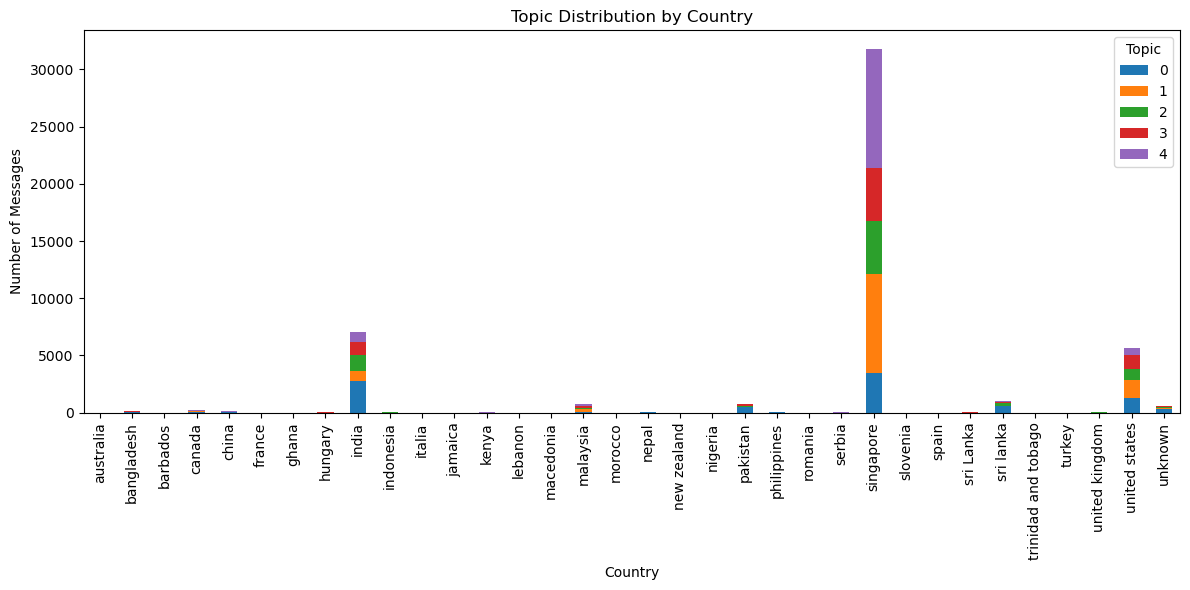

In [128]:
import matplotlib.pyplot as plt

topic_by_country.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Topic Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Messages")
plt.legend(title="Topic")
plt.tight_layout()
plt.show()

In [129]:
import numpy as np

def plot_top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\nTopic {topic_idx}")
        print([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])

plot_top_words(lda, words)


Topic 0
['thanks', 'happy', 'love', 'ur', 'day', 'new', 'email', 'may', 'miss', 'good']

Topic 1
['haha', 'lol', 'hahaha', 'okay', 'yeah', 'dont', 'know', 'think', 'see', 'yes']

Topic 2
['call', 'home', 'come', 'im', 'coming', 'hi', 'back', 'le', 'hey', 'way']

Topic 3
['ok', 'sure', 'oh', 'good', 'yup', 'sorry', 'lol', 'im', 'dear', 'haha']

Topic 4
['go', 'time', 'meet', 'wat', 'going', 'lor', 'got', 'pm', 'free', 'later']


**7.2 Analysis Findings: Topic Distribution per Country** <br>
Across the dataset, topic distributions vary significantly by country, with clear differences in both volume and thematic emphasis. 

Countries with large message counts such as Singapore, India, United States, Pakistan, and Malaysia show strong engagement across all topics, suggesting a broad and diverse range of communication. 

Singapore, in particular, dominates overall volume and is especially concentrated in Topics 1, 2, 3, and 4, indicating highly active informal and coordination-based messaging. 

India and Pakistan also show strong representation across all topics, with relatively balanced distributions, though Topic 0 and Topic 2 appear particularly prominent, suggesting a mix of emotional and logistical communication. 

In contrast, smaller datasets such as Australia, France, and New Zealand show very low counts, making their topic distributions less stable but still reflective of casual conversational themes. 

Overall, the results suggest that while certain communication patterns (such as casual chat and coordination) are consistent globally, the intensity and balance of topics vary considerably depending on country representation and messaging volume.

#### **8. Further Analysis: Singapore Insights**
Since Singapore message counts dominate the dataset, I am interested in moving from a global topic model to a country-specific topic model, to give much clearer insights.

I will run the same LDA topic modelling pipeline just for Singapore.

**8.1 Pipeline Modelling: Singapore Messages Only** <br>

In [132]:
#Create a pipeline function:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def run_lda(data, text_column, n_topics=5):
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(data[text_column])
    
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(X)
    
    return lda, vectorizer, X

In [135]:
#Filter to Singapore only and clean messages
sg_data = sms_data[sms_data["country"] == "singapore"].dropna(subset=["clean_message"])

In [136]:
#Run model:
lda_sg, vectorizer_sg, X_sg = run_lda(sg_data, "clean_message")

In [137]:
#Extract topics (reusable):
def print_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()
    
    for i, topic in enumerate(model.components_):
        print(f"\nTopic {i}")
        print([words[j] for j in topic.argsort()[-n_words:]])

In [138]:
print_topics(lda_sg, vectorizer_sg)


Topic 0
['ohh', 'oh', 'sorry', 'im', 'thanks', 'yeah', 'lol', 'hahaha', 'okay', 'haha']

Topic 1
['one', 'want', 'got', 'dont', 'know', 'think', 'dun', 'lol', 'go', 'haha']

Topic 2
['time', 'ok', 'go', 'free', 'ur', 'tmr', 'coming', 'pm', 'meet', 'hey']

Topic 3
['soon', 'lols', 'dinner', 'got', 'call', 'wat', 'time', 'home', 'yup', 'going']

Topic 4
['lol', 'ur', 'see', 'ya', 'love', 'go', 'dear', 'le', 'hee', 'ok']


**8.1.1 Interpretation of extracted topics for Singapore** <br>

<u>Topic 0: Casual emotional reactions / politeness</u> <br>

This topic reflects highly informal conversational responses, often made up of acknowledgements, laughter, and short emotional reactions. It captures everyday chat behaviour such as agreeing (“yeah”, “okay”), expressing politeness (“sorry”, “thanks”), and reacting with laughter (“haha”, “lol”).

<u>Topic 1: Opinions, decisions, and informal discussion</u>

This topic is centred around decision-making and informal reasoning, with frequent expressions of uncertainty (“don’t know”, “think”), preferences (“want”), and casual conversation filler. It reflects everyday messaging where people discuss plans or opinions in a relaxed way.

<u>Topic 2: Scheduling and meeting arrangements</u>

This topic clearly relates to coordination and planning, particularly arranging meetings and availability. Words like “free”, “tmr”, “meet”, and “pm” indicate logistical communication about time and social plans.

<u>Topic 3: Social activities and daily life coordination</u>

This topic reflects everyday activity coordination, including plans around meals, going home, making calls, and general updates. It represents routine social organisation and day-to-day interactions.

<u>Topic 4: Friendly / affectionate casual chat</u>

This topic captures light social and affectionate communication, including friendly closings (“ya”, “see”), informal slang (“hee”, “le”), and occasional affectionate language (“love”, “dear”).

**8.2 Visualiation: Topic Distribution in Singapore** <br>


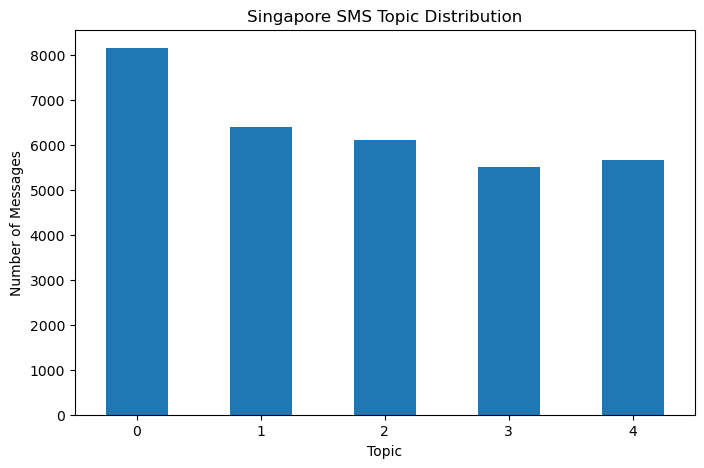

In [139]:
import matplotlib.pyplot as plt

# Assign dominant topic to each message
sg_data["topic"] = lda_sg.transform(X_sg).argmax(axis=1)

# Count topics
topic_counts = sg_data["topic"].value_counts().sort_index()

# Plot
plt.figure(figsize=(8,5))
topic_counts.plot(kind="bar")

plt.title("Singapore SMS Topic Distribution")
plt.xlabel("Topic")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

plt.show()

**8.3 Analysis Findings: Topic Distribution for Singapore** <br>
Singapore’s SMS communication is dominated by Topic 0, which reflects short emotional reactions, laughter, and conversational fillers. This indicates that many messages are informal and reactive rather than information-heavy, with users often replying using brief emotional cues.

Overall, the dataset shows a strong pattern of casual, shorthand communication, with frequent slang such as “lol”, “haha”, and “ur”. Even in planning-related topics, the tone remains highly informal and conversational.

### **PROJECT SUMMARY**

This project explored the National University of Singapore SMS Corpus, a large dataset of over 67,000 text messages collected from users across multiple countries. 

After cleaning and preprocessing the data, including standardising text, removing noise, and handling inconsistencies, the focus shifted to uncovering underlying themes within the messages. 

Using topic modelling techniques, the analysis identified recurring conversational patterns such as casual social interaction, emotional responses, and everyday coordination around plans and meetings. 

Comparing topics across countries revealed both shared communication behaviours such as informal shorthand messaging and differences in topic distribution depending on dataset size and regional representation. 

Overall, the results highlight how SMS communication is largely informal, reactive, and socially driven across all countries.

### **NEXT STEPS**

A useful next step would be to improve the quality and interpretability of the topic model by refining preprocessing further, for example by removing high frequency conversational noise like “lol”, “haha”, and “ur”, and experimenting with alternative modelling approaches such as BERTopic or optimised LDA settings. 

The analysis could also be extended by conducting a more rigorous country level comparison, including normalised topic proportions rather than raw counts to account for uneven dataset sizes. 

Additionally, incorporating time based analysis could reveal how topics evolve over time within and across countries. 

Finally, building interactive visualisations or dashboards would make the findings more accessible and allow deeper exploration of communication patterns in the SMS corpus.